# Nullstellen


## Vertiefung


### Übersicht


1. Toleranz als Abbruchkriterium
2. Mehrere Nullstellen
3. Nullstellen bestimmen mit SciPy


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Toleranz als Abbruchkriterium


Die folgende Funktion hat nur eine (reelle) Nullstelle und zwar bei $x=3$:

$$ f(x) = (x-4)^3 + 1 $$


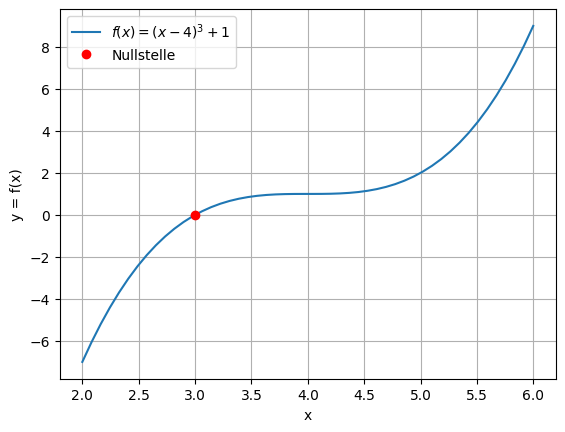

In [2]:
def f(x):
    return (x - 4) ** 3 + 1


def fprime(x):
    return 3 * (x - 4) ** 2


x = np.linspace(2, 6)
y = f(x)

plt.plot(x, y, label="$f(x) = (x-4)^3 + 1$")
plt.plot(3, 0, "ro", label="Nullstelle")
plt.ylabel("y = f(x)")
plt.xlabel("x")
plt.grid()
plt.legend()
plt.show()

#### a) Fehlerabschätzung bei Bisektionsverfahren


Nach $n$ Schritten, wissen wir, dass die gesuchte Nullstelle $x$ zwischen den Intervallgrenzen $a_n$ und $b_n$ liegt, also $x\in [a_n,b_n]$. Die einfachste Schätzung der Nullstelle ist also die Mitte des Intervalls.

$$
    x \simeq x_n = \frac{1}{2} \left( a_n + b_n \right)
$$

Und als Fehlerabschätzung von $x$ können wir die halbe Intervallbreite nehmen

$$
    \Delta_x = \frac{1}{2} \left| b_n - a_n \right|
$$

Andererseits kann auch der Funktionswert an der geschätzten Nullstelle als Indikator für die Qualität der Näherung benutzt werden

$$
    \Delta_y = \left| f(x_n) \right|
$$

Als Abbruchkriterien können Toleranzen (obere Grenzen) für beide Fehlerabschätzungen benutzt werden.


In [3]:
def bisection(f, a0, b0, xtol, ytol, maxiter):
    assert a0 < b0
    assert f(a0) * f(b0) < 0
    assert xtol > 0
    assert ytol > 0
    assert maxiter >= 0

    a, b = a0, b0
    x = (a + b) / 2
    y = f(x)
    ya = f(a)
    Dx = abs(b - a) / 2
    Dy = abs(y)
    steps = 0
    res = [(steps, x, Dx, Dy)]

    while (Dx > xtol or Dy > ytol) and steps < maxiter:
        if ya * y < 0:
            b = x
        else:
            a = x
            ya = y
        x = (a + b) / 2
        y = f(x)
        Dx = abs(b - a) / 2
        Dy = abs(y)
        steps += 1
        res.append((steps, x, Dx, Dy))

    return np.array(res)


print("Bisection:")
print("\t i \t\t x_i \t\t Dx_i \t\t Dy_i")
bisection(f, 1, 4, 1e-10, 1e-10, 200)

Bisection:
	 i 		 x_i 		 Dx_i 		 Dy_i


array([[0.00000000e+00, 2.50000000e+00, 1.50000000e+00, 2.37500000e+00],
       [1.00000000e+00, 3.25000000e+00, 7.50000000e-01, 5.78125000e-01],
       [2.00000000e+00, 2.87500000e+00, 3.75000000e-01, 4.23828125e-01],
       [3.00000000e+00, 3.06250000e+00, 1.87500000e-01, 1.76025391e-01],
       [4.00000000e+00, 2.96875000e+00, 9.37500000e-02, 9.67102051e-02],
       [5.00000000e+00, 3.01562500e+00, 4.68750000e-02, 4.61463928e-02],
       [6.00000000e+00, 2.99218750e+00, 2.34375000e-02, 2.36210823e-02],
       [7.00000000e+00, 3.00390625e+00, 1.17187500e-02, 1.16730332e-02],
       [8.00000000e+00, 2.99804688e+00, 5.85937500e-03, 5.87082654e-03],
       [9.00000000e+00, 3.00097656e+00, 2.92968750e-03, 2.92682741e-03],
       [1.00000000e+01, 2.99951172e+00, 1.46484375e-03, 1.46555912e-03],
       [1.10000000e+01, 3.00024414e+00, 7.32421875e-04, 7.32243076e-04],
       [1.20000000e+01, 2.99987793e+00, 3.66210938e-04, 3.66255643e-04],
       [1.30000000e+01, 3.00006104e+00, 1.83105469e

Machen wir noch eine Darstellung davon


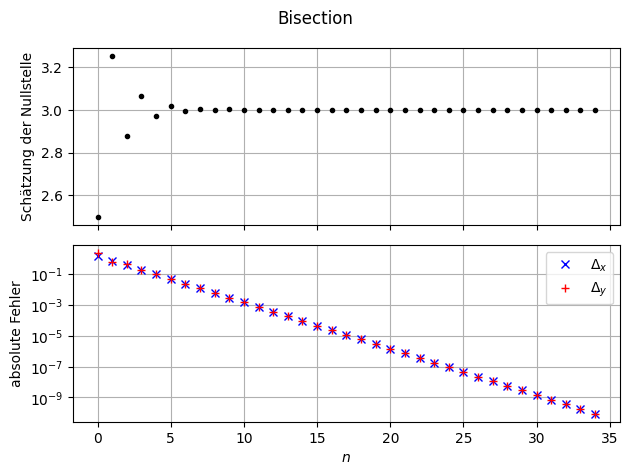

In [4]:
res = bisection(f, 1, 4, 1e-10, 1e-10, 200)
steps, x, Dx, Dy = res.T

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(steps, x, "k.", label="$x_n$")
ax1.set_ylabel("Schätzung der Nullstelle")
ax1.grid()

ax2.set_yscale("log")
ax2.plot(steps, Dx, "bx", label=r"$\Delta_x$")
ax2.plot(steps, Dy, "r+", label=r"$\Delta_y$")
ax2.set_ylabel("absolute Fehler")
ax2.set_xlabel("$n$")
ax2.grid()
ax2.legend()

plt.suptitle("Bisection")
plt.tight_layout()
plt.show()

#### b) Fehlerabschätzung beim Newton-Verfahren


Wieder können wir den Funktionswert an der Stelle $x_n$ als Indikator der Qualität der Schätzung der Nullstelle verwenden:

$$
    \Delta_y = \left| f(x_n) \right|
$$

Allerdings ist eine Abschätzung des Fehlers in $x$-Richtung schwieriger. Als Abbruchkriterium können wir aber die Distanz nehmen, die in $x$-Richtung seit der letzten Iteration zurückgelegt wurde, also

$$
    \Delta_x \simeq \left| x_{n+1} - x_n \right| = \left| \dfrac{f(x_n)}{f'(x_n)} \right|
$$


In [5]:
def newton(f, fprime, x0, xtol, ytol, maxiter):
    assert xtol > 0
    assert ytol > 0
    assert maxiter >= 0

    x = x0
    y = f(x)
    y_by_yprime = y / fprime(x)
    Dy = abs(y)
    Dx = abs(y_by_yprime)
    steps = 0
    res = [(steps, x, Dx, Dy)]

    while (Dx > xtol or Dy > ytol) and steps < maxiter:
        x = x - y_by_yprime
        y = f(x)
        y_by_yprime = y / fprime(x)
        Dy = abs(y)
        Dx = abs(y_by_yprime)
        steps += 1
        res.append((steps, x, Dx, Dy))

    return np.array(res)


print("Newton:")
print("\t i \t\t x_i \t\t Dx_i \t\t Dy_i")
newton(f, fprime, 1, 1e-10, 1e-10, 200)

Newton:
	 i 		 x_i 		 Dx_i 		 Dy_i


array([[0.00000000e+00, 1.00000000e+00, 9.62962963e-01, 2.60000000e+01],
       [1.00000000e+00, 1.96296296e+00, 5.98681767e-01, 7.45272570e+00],
       [2.00000000e+00, 2.56164473e+00, 3.18332887e-01, 1.97576414e+00],
       [3.00000000e+00, 2.87997762e+00, 1.07620123e-01, 4.05012235e-01],
       [4.00000000e+00, 2.98759774e+00, 1.22509490e-02, 3.76701370e-02],
       [5.00000000e+00, 2.99984869e+00, 1.51288470e-04, 4.54002771e-04],
       [6.00000000e+00, 2.99999998e+00, 2.28905090e-08, 6.86715300e-08],
       [7.00000000e+00, 3.00000000e+00, 4.44089210e-16, 1.33226763e-15]])

Darstellung


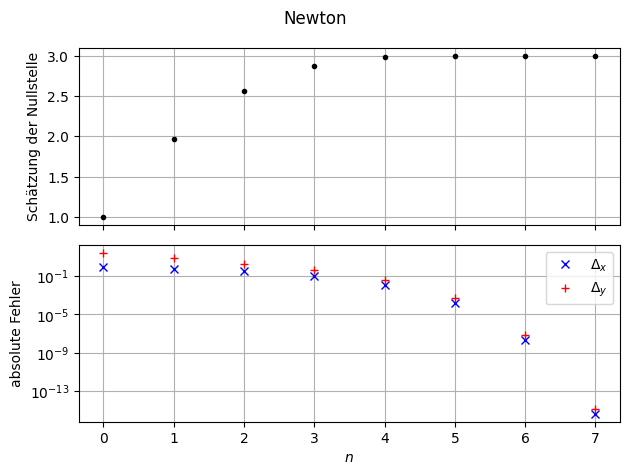

In [6]:
res = newton(f, fprime, 1, 1e-10, 1e-10, 200)
steps, x, Dx, Dy = res.T

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(steps, x, "k.", label="$x_n$")
ax1.set_ylabel("Schätzung der Nullstelle")
ax1.grid()

ax2.set_yscale("log")
ax2.plot(steps, Dx, "bx", label=r"$\Delta_x$")
ax2.plot(steps, Dy, "r+", label=r"$\Delta_y$")
ax2.set_ylabel("absolute Fehler")
ax2.set_xlabel("$n$")
ax2.legend()
ax2.grid()

plt.suptitle("Newton")
plt.tight_layout()
plt.show()

### 2. Mehrere Nullstellen


Sinus- und Cosinus-Funktionen haben unendlich viele Nullstellen

$$ g(x) = 2\cos(x) + 0.5 $$

In diesem Fall können wir sie auch nicht einfach analytisch berechnen:

$$ x = \arccos(-0.25) $$


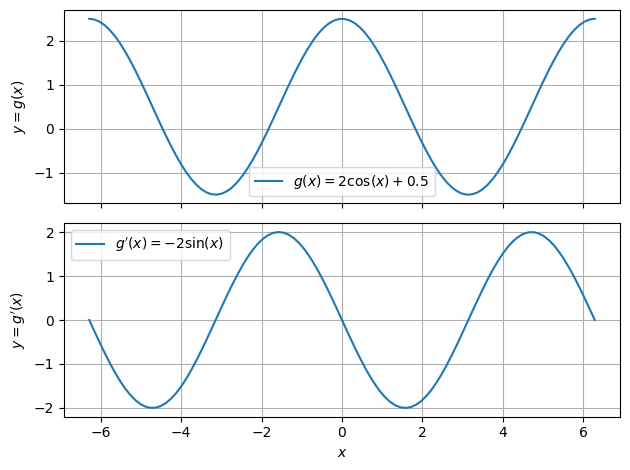

In [7]:
def g(x):
    return 2 * np.cos(x) + 0.5


def gprime(x):
    return -2 * np.sin(x)


x = np.linspace(-2 * np.pi, 2 * np.pi, 100)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(x, g(x), label=r"$g(x) = 2\cos(x) + 0.5$")
ax1.set_ylabel("$y = g(x)$")
ax1.grid()
ax1.legend()
ax2.plot(x, gprime(x), label=r"$g'(x) = -2\sin(x)$")
ax2.set_ylabel("$y = g'(x)$")
ax2.set_xlabel("$x$")
ax2.grid()
ax2.legend()
plt.tight_layout()
plt.show()

Welche Nullstelle von einem Algorithmus gefunden wird, hängt von den Anfangsbedingungen ab.

-   Beim Newton-Verfahren ist dies der Startwert $x_0$ und
-   beim Bisektionsverfahren ist es das Start-Intervall $\left[a_0,b_0\right]$.

Probieren wir es mal mit Newton aus:


In [8]:
xtol = ytol = 1e-15
maxiter = 100
for x0 in [-4, -2, 2, 4]:
    res = newton(g, gprime, x0, xtol, ytol, maxiter)
    steps, x, Dx, Dy = res.T
    print(f"Newton mit x0 = {x0} findet:", x[-1])

Newton mit x0 = -4 findet: -4.459708725242611
Newton mit x0 = -2 findet: -1.8234765819369751
Newton mit x0 = 2 findet: 1.8234765819369751
Newton mit x0 = 4 findet: 4.459708725242611


Es ist unmöglich zu wissen, ob man alle Nullstellen gefunden hat. Denn es können sich immer noch mehr Nullstellen zwischen ausprobierten Startwerten befinden.


### 3. Nullstellen bestimmen mit SciPy


Das SciPy Unterpaket [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html#root-finding) bietet verschiedene Funktionen für die Suche von Nullstellen (engl. _root finding_).

Die Funktion [`scipy.optimize.root_scalar`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html) ist der übergeordnete Einstiegspunkt. Sie wählt automatisch die beste Methode für das gegebene Problem. Man kann aber auch explizit eine Methode wählen.

Weiter gibt es neben anderen Algorithmen auch [`scipy.optimize.bisect`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.bisect.html) und [`scipy.optimize.newton`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html), um direkt diese Verfahren zu benutzen.

Siehe Beispiel auf dem Übungsblatt.


In [9]:
from scipy import optimize

sol = optimize.root_scalar(g, x0=4, fprime=gprime)
sol

      converged: True
           flag: converged
 function_calls: 10
     iterations: 5
           root: 4.459708725242611
         method: newton

In [10]:
print(type(sol))
sol.root

<class 'scipy.optimize._zeros_py.RootResults'>


np.float64(4.459708725242611)

In [11]:
optimize.newton(g, 1, gprime, full_output=True)

(np.float64(1.8234765819369754),
       converged: True
            flag: converged
  function_calls: 10
      iterations: 5
            root: 1.8234765819369754
          method: newton)

In [12]:
optimize.bisect(g, 0, 4, full_output=True)

(1.823476581937939,
       converged: True
            flag: converged
  function_calls: 43
      iterations: 41
            root: 1.823476581937939
          method: bisect)

Mehrere Nullstellen

In [13]:
np.array([optimize.root_scalar(g, x0=x0).root for x0 in [1, -1, 5]])

array([ 1.82347658, -1.82347658,  4.45970873])

In [14]:
optimize.newton(g, [1, -1, 5], gprime)

array([ 1.82347658, -1.82347658,  4.45970873])